# Backtesting checks

In [3]:
import sys
import math
import numpy as np
from pathlib import Path

here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / ".git").exists())
for path in (str(ROOT), str(ROOT / "research")):
    if path not in sys.path:
        sys.path.insert(0, path)

# Пакет backtesting лежит в корне репо (research/ на пути только для tools).
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

In [4]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q, ttl_s=0.3):
        super().__init__()                       # sets self.gateway
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._ttl_s = ttl_s          # order lifetime; short TTL (≈ median LOB gap) — re-quoted
                                     # every tick, no cancel in the MVP so orders expire, not replace
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        self.gateway.create_order(+self.Q, r - half_spread, ttl_s=self._ttl_s)   # bid
        self.gateway.create_order(-self.Q, r + half_spread, ttl_s=self._ttl_s)   # ask

In [5]:
hours = range(0, 24)  # 3 часа DOGE — быстрый прогон; расширь диапазон при желании
lob_paths    = [ROOT / f"data/lighter/DOGE/lob/20260712/{h:02d}.parquet"      for h in hours]
trades_paths = [ROOT / f"data/lighter/DOGE/trades/20260712/{h:02d}.jsonl.zst" for h in hours]

feed = LighterFeed(lob_paths, trades_paths, depth=10)
feed

LighterFeed(depth=10, lob=280,858 snapshots [2026-07-12 00:00:00.042000 → 2026-07-12 23:59:59.746000], trades=1,093 [2026-07-12 00:00:31.945000 → 2026-07-12 23:56:08.242000])

In [6]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 10
lob snapshots : 280,858  (crossed/locked: 0)
trades        : 1,093  (sells: 629)
invariants OK


In [7]:
# PnL пока не показателен: без комиссий/латентности/tick-rounding (следующие итерации).
# Цель прогона — движок гоняется на реальных данных Lighter и инварианты держатся.
params = {"sigma": 1e-06, "kappa": 1e6, "gamma": 0.01, "T": 14400.0, "Q": 100.0}
prefix = "/tmp/_lighter_dod"

bt = Backtester(log_interval_sec=10.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [9]:
s = BacktestResult(prefix)
display(s.summary_df())

value  \
group     metric                                               
PnL       total_pnl ($)                              -8.0311   
          sharpe_annualized                           -16.18   
          max_drawdown ($)                          -13.0915   
          spread_capture ($)                         -0.3144   
          spread_capture (% of total)                 -3.91%   
          capture_yield (bps)                          -0.28   
          inventory_mtm ($)                          -7.7167   
          inventory_mtm (% of total)                 -96.09%   
          fees ($)                                   +0.0000   
          identity_gap ($)                           -0.0000   
          inv_mtm_grid_error ($)                     +0.0000   
          net_edge_per_fill (bps)                      -2.03   
          net_edge CI95 [lo, hi]              [-2.78, -1.13]   
          markout_30s (bps)                            -1.76   
          capture_share_of_variance                  +0.9939   
          corr(hourly_pnl, hourly_return)            -0.7984   
Fills     n_fills                                      1,569   
          n_bid_fills                                    771   
          n_ask_fills                                    798   
          fill_imbalance                             -0.0172   
Inventory avg_inventory                           -5772.9855   
          std_inventory                            5085.1231   
          max_abs_inventory                       13138.0000   
          turnover ($)                            +11,305.94   
          mean |inv|                               6745.4856   
          p90 |inv|                               10953.0000   
          zero_crossings / day                        4.0005   
          median_excursion (min)                    138.4917   
          worst_unrealized ($)                       -5.8734   
          time at ≥90% max|inv| (%)                     3.90   
Tails     n_jumps                                          3   
          pnl_in_jump_windows ($)                    -0.4172   
          pnl_in_jump_windows (% of |total|)          -5.20%   
          worst_hour ($)                             -6.1449   
          p5_hourly ($)                              -3.0728   
Ops       two_sided_uptime (%)                         67.63   
          quote_updates/min p50                         4.00   
          quote_updates/min p95                         8.00   

                                                                                           note  
group     metric                                                                                 
PnL       total_pnl ($)                                                                          
          sharpe_annualized                               grid from log_interval≈10.3s (coarse)  
          max_drawdown ($)                                                                       
          spread_capture ($)                                                                     
          spread_capture (% of total)                                                            
          capture_yield (bps)                                                                    
          inventory_mtm ($)                                                                      
          inventory_mtm (% of total)                                                             
          fees ($)                                                                               
          identity_gap ($)                                                                       
          inv_mtm_grid_error ($)                                                                 
          net_edge_per_fill (bps)                                                                
          net_edge CI95 [lo, hi]                                                                 
          markout_30s (b

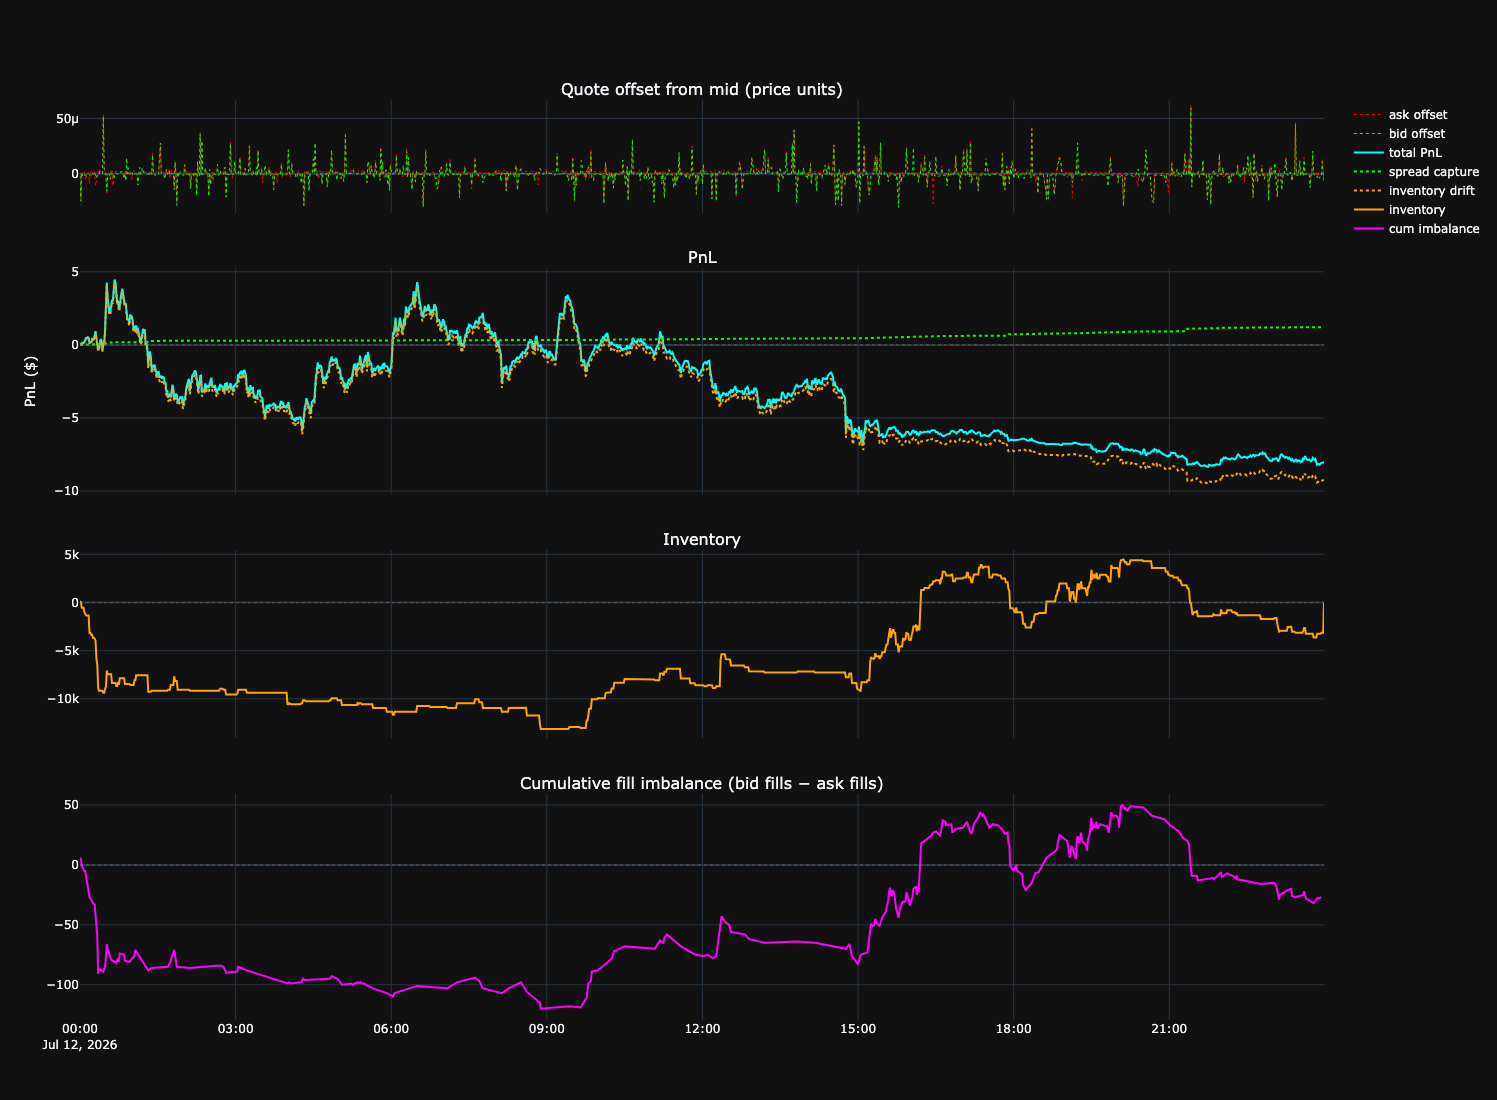

In [10]:
s.plot().show()   # tick_size не задаю: тик DOGE на Lighter — UNVERIFIED, оси в price units

### Проверки корректности движка (latency + мультиуровень)

Синтетические сценарии (A–C) с заранее известным ответом — изолируют логику матчинга и latency.
Инварианты на реальных данных (D–G) — монотонность, голодание, детерминизм, сходимость PnL.
Каждая ячейка печатает `OK`; при нарушении падает по `assert`. Опираются на `feed` и `params` выше.

In [13]:
class ArrayFeed:
    """Minimal in-memory feed (same .arrays() contract as LighterFeed) for tests."""
    def __init__(self, arrays):
        self._arrays = arrays
    def arrays(self):
        return self._arrays


def make_feed(snaps, trades, depth=2):
    """Build a tiny feed from top-of-book rows (engine infers depth from width).
    snaps:  (ts, bid_px, bid_sz, ask_px, ask_sz)   — only level 1 is set, rest zero size
    trades: (ts, is_sell, price, size)

    depth defaults to 2 so there is an empty floor/ceiling level out of every trade's
    reach — deeper bids at price 0 (below any trade), deeper asks at a huge price
    (above any trade). apply_trade then stops by price on either side instead of
    exhausting the loaded book, so a synthetic trade larger than the top level does NOT
    trip the punch-through escalation. Pass depth=1 to exercise it on purpose (check K).
    """
    n = len(snaps)
    FAR_ASK = 1e18                                   # ceiling: above any test trade price
    bid_px = np.zeros((n, depth))                    # deeper bids at 0  → a sell stops by price
    ask_px = np.full((n, depth), FAR_ASK)            # deeper asks far up → a buy stops by price
    bid_sz = np.zeros((n, depth))
    ask_sz = np.zeros((n, depth))
    for i, (_, bp, bs, ap, asz) in enumerate(snaps):
        bid_px[i, 0], bid_sz[i, 0] = bp, bs
        ask_px[i, 0], ask_sz[i, 0] = ap, asz
    return ArrayFeed(dict(
        lob_ts=np.array([s[0] for s in snaps], np.int64),
        bid_px=bid_px, bid_sz=bid_sz, ask_px=ask_px, ask_sz=ask_sz,
        trade_ts=np.array([t[0] for t in trades], np.int64),
        trade_is_sell=np.array([t[1] for t in trades], np.uint8),
        trade_price=np.array([t[2] for t in trades], np.float64),
        trade_size=np.array([t[3] for t in trades], np.float64),
    ))


class FixedQuotes(Strategy):
    """Quotes a fixed set every tick (ignores the book) — for deterministic tests.
    quotes: list of (side, price, size). ttl_s=0.0 → GTC (fine for the bounded checks)."""
    def __init__(self, quotes, ttl_s=0.0):
        super().__init__()
        self._quotes = quotes
        self._ttl_s  = ttl_s
    def on_lob(self, ob, inventory):
        for side, price, size in self._quotes:
            self.gateway.create_order(size if side == "bid" else -size, price, ttl_s=self._ttl_s)


class ASLadder(Strategy):
    """Avellaneda–Stoikov, quoting n_levels each side spaced `step` apart."""
    def __init__(self, sigma, kappa, gamma, T, Q, n_levels=3, step=2e-6, ttl_s=0.3):
        super().__init__()
        self.gamma, self.T, self._sigma2, self.Q = gamma, T, sigma ** 2, Q
        self.n_levels, self.step = n_levels, step
        self._ttl_s = ttl_s              # re-quoted every tick; short TTL bounds the live set (no cancel)
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us = None

    def on_lob(self, ob, inventory):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))
        risk = self.gamma * self._sigma2 * tau
        r = ob.mid - inventory * risk
        half = 0.5 * risk + self._half_log_term
        for i in range(self.n_levels):
            off = half + i * self.step
            self.gateway.create_order(+self.Q, r - off, ttl_s=self._ttl_s)   # bid level i
            self.gateway.create_order(-self.Q, r + off, ttl_s=self._ttl_s)   # ask level i


def run_result(strat, feed, latency_us, tag):
    prefix = f"/tmp/_chk_{tag}"
    Backtester(latency_us=latency_us, log_interval_sec=10.0).run(strat, feed=feed, output_path=prefix)
    return BacktestResult(prefix)

In [14]:
# ── A. latency gating: an order must not fill before it lands ──
#    bid@100 size5; sell@100 size100 at t=100. queue at 100 is 10 → fill = min(5, 100-10) = 5.
feed_a = make_feed([(0, 100.0, 10.0, 101.0, 10.0)],
                   [(100, 1, 100.0, 100.0)])
a0 = run_result(FixedQuotes([("bid", 100.0, 5.0)]), feed_a, 0,   "a0")   # lands at t=0 → fills
a9 = run_result(FixedQuotes([("bid", 100.0, 5.0)]), feed_a, 200, "a9")   # lands at t=200 > trade → no fill
assert a0.summary()["n_fills"] == 1
assert abs(a0.fills[a0.fills["side"] == "bid"]["size"].iloc[0] - 5.0) < 1e-9
assert a9.summary()["n_fills"] == 0
print(f"A gating      : fills(lat=0)={a0.summary()['n_fills']}  fills(lat=200)={a9.summary()['n_fills']}  OK")

# ── B. multi-level: independent fills at several price levels ──
#    bid@100 and bid@99; a sell@99 reaches both. queue: 1 at 100, 0 at 99 → both fill fully (5 each).
feed_b = make_feed([(0, 100.0, 1.0, 101.0, 1.0)],
                   [(100, 1, 99.0, 100.0)])
b = run_result(FixedQuotes([("bid", 100.0, 5.0), ("bid", 99.0, 5.0)]), feed_b, 0, "b")
b_prices = sorted(round(p, 6) for p in b.fills[b.fills["side"] == "bid"]["price"])
assert b.summary()["n_fills"] == 2 and b_prices == [99.0, 100.0]
print(f"B multilevel  : n_fills={b.summary()['n_fills']}  prices={b_prices}  OK")

# ── C. partial fill: only (trade − queue ahead) fills; remainder rests ──
#    bid@100 size10; sell@100 size7 with queue 5 ahead → fill = 7 - 5 = 2.
feed_c = make_feed([(0, 100.0, 5.0, 101.0, 5.0)],
                   [(100, 1, 100.0, 7.0)])
c = run_result(FixedQuotes([("bid", 100.0, 10.0)]), feed_c, 0, "c")
c_size = c.fills[c.fills["side"] == "bid"]["size"].iloc[0]
assert c.summary()["n_fills"] == 1 and abs(c_size - 2.0) < 1e-9
print(f"C partial     : fill_size={c_size}  (expected 2.0)  OK")

A gating      : fills(lat=0)=1  fills(lat=200)=0  OK
B multilevel  : n_fills=2  prices=[99.0, 100.0]  OK
C partial     : fill_size=2.0  (expected 2.0)  OK


In [15]:
# ── D. latency delays fills — controlled monotone case ──
#    One resting bid (queue 0 → fills on any sell); four sells at 500..3500 µs.
#    Latency L blanks the lead-in [0, L): a trade fills only once an order has landed,
#    so each 1000-µs step of latency knocks out exactly one more trade.
snaps  = [(t, 100.0, 0.0, 101.0, 1.0) for t in range(0, 5000, 1000)]
sells  = [(t, 1, 100.0, 1.0) for t in (500, 1500, 2500, 3500)]
feed_d = make_feed(snaps, sells)
n_by_lat = [run_result(FixedQuotes([("bid", 100.0, 1.0)]), feed_d, L, f"dsyn{L}").summary()["n_fills"]
            for L in (0, 1000, 2000, 3000)]
assert n_by_lat == [4, 3, 2, 1], f"expected [4, 3, 2, 1], got {n_by_lat}"
print(f"D monotone    : fills per latency {n_by_lat}  (each step blanks one more trade)  OK")

# ── D2 (diagnostic, no assert): real-data sweep is NOT monotone by design ──
#    ASLadder quotes ~1e-6 from mid — deep inside the ~3.5e-5 DOGE spread — on prices
#    absent from the book, where queue_ahead is 0 and any through-trade fills. Its price
#    also MOVES with latency, so stale near-mid quotes get adversely selected and fills
#    can RISE with latency (worse PnL, more fills). Expected, not a bug.
for lat in [0, 1_000, 10_000, 100_000, 1_000_000]:
    n = run_result(ASLadder(**params), feed, lat, f"d{lat}").summary()["n_fills"]
    print(f"latency={lat:>9} µs   n_fills={n:>6}")

# ── E. latency beyond the data span: nothing ever lands → zero fills ──
span = int(max(feed.lob_ts[-1], feed.trade_ts[-1]) - min(feed.lob_ts[0], feed.trade_ts[0]))
e = run_result(ASLadder(**params), feed, span + 1_000_000, "e")
assert e.summary()["n_fills"] == 0
print(f"E starved     : latency>span → n_fills={e.summary()['n_fills']}  OK")

D monotone    : fills per latency [4, 3, 2, 1]  (each step blanks one more trade)  OK
latency=        0 µs   n_fills=  4381
latency=     1000 µs   n_fills=  4389
latency=    10000 µs   n_fills=  4309
latency=   100000 µs   n_fills=  3912
latency=  1000000 µs   n_fills=  2409


RuntimeError: increase ring buffer capacity

In [16]:
# ── F. determinism: identical inputs → identical output ──
f1 = run_result(ASLadder(**params), feed, 10_000, "f1")
f2 = run_result(ASLadder(**params), feed, 10_000, "f2")
assert f1.fills.reset_index(drop=True).equals(f2.fills.reset_index(drop=True))
assert np.allclose(f1.pnl.values, f2.pnl.values)
print("F determinism : two identical runs match  OK")

# ── G. PnL accounting: reconstruct final PnL from fills, compare to reported ──
def final_pnl_from_fills(r):
    f = r.fills
    tr = f[f["side"].isin(["bid", "ask"])]
    cash = float((np.where(tr["side"] == "ask", 1.0, -1.0) * tr["price"] * tr["size"]).sum())
    inv  = float((np.where(tr["side"] == "bid", 1.0, -1.0) * tr["size"]).sum())
    mk = f[f["side"] == "markout"]
    assert abs(mk["size"].iloc[-1] + inv) < 1e-6, "markout must close net inventory"
    return cash + inv * float(mk["price"].iloc[-1])

recon    = final_pnl_from_fills(f1)
reported = float(f1.pnl.iloc[-1])
assert abs(recon - reported) <= 1e-6 * max(1.0, abs(reported))
print(f"G accounting  : reconstructed={recon:+.6f}  reported={reported:+.6f}  OK")

F determinism : two identical runs match  OK
G accounting  : reconstructed=-11.723656  reported=-11.723656  OK


### New order API: gateway create · TTL expiry · reduce-only

Smoke tests for the imperative `self.gateway.create_order(...)` path (create-only MVP).
Self-contained — they use a small new-API strategy (`CreateOnce`) and the `make_feed` /
`run_result` helpers above; they do **not** depend on the A–G helpers, which still use the
retired return-list API and are pending migration.

In [17]:
class CreateOnce(Strategy):
    """Issues a fixed order set on the first LOB event only (new gateway API).
    orders: list of (size, price, ttl_s, reduce_only) — size sign carries the side.
    ttl_s is a number: <= 0 means GTC."""
    def __init__(self, orders):
        super().__init__()                      # sets self.gateway
        self._orders = orders
        self._fired = False

    def on_lob(self, ob, inventory):
        if self._fired:
            return
        self._fired = True
        for size, price, ttl_s, ro in self._orders:
            self.gateway.create_order(size, price, ttl_s=ttl_s, reduce_only=ro)


# ── H. gateway create + latency landing (mirrors A, but via create_order) ──
#    One GTC bid created on the first snapshot; sell@100 (queue 10) fills 5 of it.
feed_h = make_feed([(0, 100.0, 10.0, 101.0, 10.0)], [(100, 1, 100.0, 100.0)])
h0 = run_result(CreateOnce([(+5.0, 100.0, 0.0, False)]), feed_h, 0,   "h0")  # lands t=0 → fills
h9 = run_result(CreateOnce([(+5.0, 100.0, 0.0, False)]), feed_h, 200, "h9")  # lands t=200 → no fill
assert h0.summary()["n_fills"] == 1
assert abs(h0.fills[h0.fills["side"] == "bid"]["size"].iloc[0] - 5.0) < 1e-9
assert h9.summary()["n_fills"] == 0
print(f"H gateway     : fills(lat=0)={h0.summary()['n_fills']}  fills(lat=200)={h9.summary()['n_fills']}  OK")

# ── I. GTT expiry: a trade after the order's TTL finds nothing resting ──
#    bid@100 created once with ttl_s=1e-3 (1000 µs), latency 0 → expire_at = 1000 µs.
#    queue 0 at 100 → any sell fills the order while it is still alive.
snaps_i = [(0, 100.0, 0.0, 101.0, 0.0)]
i_live = run_result(CreateOnce([(+5.0, 100.0, 1e-3, False)]), make_feed(snaps_i, [(500,  1, 100.0, 100.0)]), 0, "iL")
i_dead = run_result(CreateOnce([(+5.0, 100.0, 1e-3, False)]), make_feed(snaps_i, [(2000, 1, 100.0, 100.0)]), 0, "iD")
assert i_live.summary()["n_fills"] == 1, "trade before TTL must fill"
assert i_dead.summary()["n_fills"] == 0, "trade after TTL must find the order reaped"
print(f"I ttl expiry  : fills(t<ttl)={i_live.summary()['n_fills']}  fills(t>ttl)={i_dead.summary()['n_fills']}  OK")

# ── J. reduce-only: fills only when it shrinks |inventory| ──
#    J1: reduce-only ask with flat inventory → capacity 0 → no fill.
feed_j1 = make_feed([(0, 100.0, 0.0, 101.0, 0.0)], [(100, 0, 101.0, 100.0)])
j1 = run_result(CreateOnce([(-5.0, 101.0, 0.0, True)]), feed_j1, 0, "j1")
assert int((j1.fills["side"] == "ask").sum()) == 0
#    J2: sell@100 fills our bid first (inventory +5), then buy@101 lets the reduce-only ask fill.
feed_j2 = make_feed([(0, 100.0, 0.0, 101.0, 0.0)],
                    [(100, 1, 100.0, 100.0),
                     (200, 0, 101.0, 100.0)])
j2 = run_result(CreateOnce([(+5.0, 100.0, 0.0, False), (-5.0, 101.0, 0.0, True)]), feed_j2, 0, "j2")
n_ask = int((j2.fills["side"] == "ask").sum())
assert n_ask == 1, f"reduce-only ask should fill once inventory is long, got {n_ask}"
print(f"J reduce-only : flat→ask_fills={int((j1.fills['side']=='ask').sum())}  long→ask_fills={n_ask}  OK")

H gateway     : fills(lat=0)=1  fills(lat=200)=0  OK
I ttl expiry  : fills(t<ttl)=1  fills(t>ttl)=0  OK
J reduce-only : flat→ask_fills=0  long→ask_fills=1  OK


In [18]:
# ── K. depth escalation: a trade punching through ALL loaded levels must raise ──
#    depth=1 book (bid 100 size 10); a sell@100 of 100 exhausts the only level with 90 left.
#    No deeper level exists to stop the walk by price, so the engine escalates loudly.
#    (On depth>=2 the empty floor level stops it by price — that is why make_feed defaults to 2.)
feed_k = make_feed([(0, 100.0, 10.0, 101.0, 10.0)], [(100, 1, 100.0, 100.0)], depth=1)
raised, msg = False, ""
try:
    run_result(FixedQuotes([("bid", 100.0, 5.0)]), feed_k, 0, "k")
except RuntimeError as e:
    raised, msg = True, str(e)
assert raised, "expected RuntimeError when a trade punches through all loaded levels"
assert "punched through" in msg
print(f"K depth escal.: RuntimeError raised  OK  ({msg[:60]}…)")

K depth escal.: RuntimeError raised  OK  (apply_trade: trade (price=100.000000, amount=100.000000) pun…)
